In [6]:
import numpy as np
from scipy.sparse import coo_matrix


def load_base_matrix_from_text(filename):
    """
    Loads a base matrix from a text file.
    Each line corresponds to a row of integers.
    Returns a 2D NumPy array with shape (R, C).
    """
    rows = []
    
    with open(filename, 'r') as f:
        for line in f:
            # Strip whitespace, split by spaces
            str_vals = line.strip().split()
            # Convert each token to an int
            int_vals = list(map(int, str_vals))
            rows.append(int_vals)
    
    # Convert list of lists into a NumPy array
    # This assumes all rows have the same length
    base_matrix = np.array(rows, dtype=int)
    
    return base_matrix

def expand_submatrix(shift, Z):
    """
    Given a shift value and a lifting factor Z,
    return the Z x Z submatrix (in sparse format) that represents
    a cyclic shift (if shift >= 0) or a zero matrix (if shift == -1).
    """
    if shift == -1:
        # No connection => Zero submatrix
        data = []
        row = []
        col = []
        return coo_matrix((data, (row, col)), shape=(Z, Z))

    # For a shift >= 0, create a ZxZ identity matrix shifted by 'shift' columns (mod Z).
    # The (i, i+shift mod Z) = 1 for i in [0..Z-1].
    data = np.ones(Z, dtype=int)
    row = np.arange(Z)
    col = (row + shift) % Z
    return coo_matrix((data, (row, col)), shape=(Z, Z))

def create_5g_nr_parity_check_matrix(base_graph='BG1', Z=4):
    """
    Construct a 5G NR-like parity-check matrix H for demonstration.
    base_graph: 'BG1' or 'BG2'
    Z: lifting factor (must be a positive integer, typically up to 384)
    
    Returns: A scipy.sparse.coo_matrix representing the parity-check matrix.
    """
    # ------------------------------------------------
    # 1) Define a *partial* base graph from 3GPP 38.212 
    #    to keep it short. In reality, you need the full matrix.
    # 
    #    -1 means no edge
    #    0..(Z-1) means a shifted identity submatrix
    #
    #    BG1 is 46 x 68 in real 5G, BG2 is 42 x 52.
    # ------------------------------------------------
    
    if base_graph == 'BG1':
        # Partial BG1 example (4 rows x 6 cols)
        # Real BG1 is 46 x 68. This is just an example subset:
        base_graph_matrix = load_base_matrix_from_text('base_matrices/NR_1_7_15.txt')
    else:
        # Partial BG2 example (again, not the full matrix)
        # Real BG2 is 42 x 52. 
        base_graph_matrix = load_base_matrix_from_text('base_matrices/NR_1_1_384.txt')
    
    R, C = base_graph_matrix.shape
    
    # ------------------------------------------------
    # 2) Expand the base graph
    # ------------------------------------------------
    big_data = []
    big_row = []
    big_col = []
    
    for r in range(R):
        for c in range(C):
            sub_H = expand_submatrix(base_graph_matrix[r, c], Z)
            
            # The top-left corner of the submatrix in the full H
            row_offset = r * Z
            col_offset = c * Z
            
            # Convert sub_H into COO to extract data, row, col
            sub_H_coo = sub_H.tocoo()
            
            # Append to global row/col/data
            big_data.extend(sub_H_coo.data)
            big_row.extend(sub_H_coo.row + row_offset)
            big_col.extend(sub_H_coo.col + col_offset)
    
    # Final matrix size is (R*Z) x (C*Z)
    H = coo_matrix((big_data, (big_row, big_col)), shape=(R*Z, C*Z), dtype=int)
    
    return H

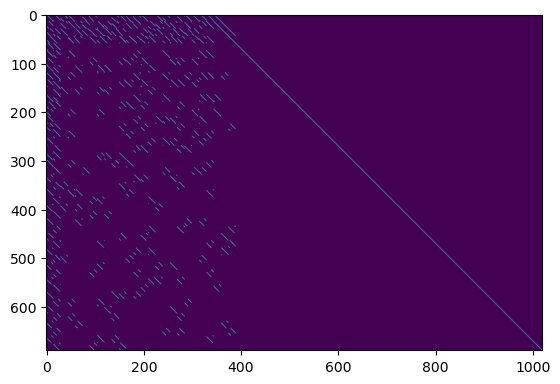

In [19]:
import matplotlib.pyplot as plt
import commpy.channelcoding.ldpc as ldpc

H = create_5g_nr_parity_check_matrix(base_graph='BG1', Z=15)*np.eye(15*68)
ldpc.write_ldpc_params(np.array(H, dtype=np.int8), '5g_nr_ldpc_params.txt')
plt.imshow(H)

In [22]:

wimax = ldpc.get_ldpc_code_params(ldpc_design_filename='5g_nr_ldpc_params.txt', compute_matrix=True)

codeword = ldpc.triang_ldpc_systematic_encode(np.random.randint(0,2, 20), wimax, 1)
# plt.plot(codeword[:][1])


codeword_to_llr = np.array([10 if x == 0 else -10 for x in codeword])
codeword_to_llr[0] = -1
decoded = ldpc.ldpc_bp_decode(codeword_to_llr, wimax,decoder_algorithm = "SPA", n_iters=100)

In [23]:
decoded[0]

array([1, 1, 0, ..., 0, 0, 0], dtype=int8)

In [35]:
import numpy as np
from commpy.channelcoding.ldpc import get_ldpc_code_params, triang_ldpc_systematic_encode

def generate_ldpc_codeword(base_graph, Z, message_bits):
    """
    Generate an LDPC codeword using CommPy for a given base graph and expansion factor.

    Parameters:
        base_graph (2D list): Base graph matrix for LDPC (e.g., 5G-NR LDPC base graphs).
        Z (int): Expansion factor.
        message_bits (numpy array): Message bits to encode.

    Returns:
        numpy array: Encoded LDPC codeword.
    """
    # Step 1: Generate the expanded parity-check matrix
    n_rows, n_cols = len(base_graph), len(base_graph[0])
    n_vnodes = n_cols * Z  # Number of variable nodes
    n_cnodes = n_rows * Z  # Number of check nodes
    parity_check_matrix = np.zeros((n_cnodes, n_vnodes), dtype=int)

    for i in range(n_rows):
        for j in range(n_cols):
            if base_graph[i][j] != -1:  # Skip -1 (no connection)
                shift = base_graph[i][j] % Z  # Cyclic shift
                for k in range(Z):  # Build cyclically shifted identity matrices
                    parity_check_matrix[i * Z + k][j * Z + (k + shift) % Z] = 1

    # Step 2: Create LDPC parameters
    ldpc_params = {
        'parity_check_matrix': parity_check_matrix,
        'cnode_deg_list': [Z] * n_cnodes,
        'vnode_deg_list': [Z] * n_vnodes,
        'n_cnodes': n_cnodes,
        'n_vnodes': n_vnodes,
        'cnode_adj_list': np.array([[] for _ in range(n_cnodes*Z)]),
        'vnode_adj_list': np.array([[] for _ in range(n_vnodes*Z)]),
        'cnode_type': 'CT',
        'vnode_type': 'VN',
        'max_cnode_deg': Z,
        'max_vnode_deg': Z



        
        
    }

    # Step 3: Encode message using CommPy's systematic encoder
    codeword = triang_ldpc_systematic_encode(message_bits, ldpc_params)
    return codeword

# Example Usage
if __name__ == "__main__":
    # Example 5G-NR LDPC base graph (BG2)
    base_graph = [
        [1, -1, 0, -1],
        [-1, 1, 2, -1],
        [2, 0, -1, 1]
    ]

    # Expansion factor
    Z = 4  # Example Z value

    # Message bits
    message_bits = np.array([1, 0, 1, 0])  # Replace with your message

    # Generate LDPC codeword
    codeword = generate_ldpc_codeword(base_graph, Z, message_bits)
    print("Encoded Codeword:", codeword)


ValueError: cannot reshape array of size 0 into shape (12,4)

In [18]:
import os
import math
import numpy as np
import commpy.channelcoding.ldpc as commpyldpc

# Suppose you already have these:
# from your_module import create_5g_nr_parity_check_matrix
# from your_module import commpyldpc  # i.e. the CommPy version that supports these calls

def create_5G_ldpc_params(file, base_matrix_file, Z):
    """
    1) Builds the parity-check matrix H by expanding 'base_matrix_file' with factor Z.
    2) Writes LDPC params to a file (5g_nr_ldpc_params.txt).
    """
    H = create_5g_nr_parity_check_matrix(base_matrix_file, Z)
    commpyldpc.write_ldpc_params(H.toarray(), file)

def get_5G_ldpc_params(ldpc_param_file):
    """
    Reads the LDPC parameter file and returns a dictionary that
    CommPy uses for encode/decode.
    """
    return commpyldpc.get_ldpc_code_params(ldpc_design_filename=ldpc_param_file, compute_matrix=True)

def encode_bits(message_bits, H_params, pad=1):
    """
    Uses CommPy's systematic encode. 
    message_bits: 1D numpy array of 0/1, length = K
    H_params: the dictionary from get_5G_ldpc_params()
    Returns: 1D numpy array (mother codeword).
    """
    return commpyldpc.triang_ldpc_systematic_encode(
        message_bits=message_bits,
        ldpc_code_params=H_params,
        pad=pad
    )

def decode_bits(llr, H_params, decoder_algorithm="SPA", n_iters=100):
    """
    CommPy BP (SPA) decode.
    llr: 1D array of LLRs
    """
    return commpyldpc.ldpc_bp_decode(
        llr_vec=llr,
        ldpc_code_params=H_params,
        decoder_algorithm=decoder_algorithm,
        n_iters=n_iters
    )

def simple_rate_match(codeword, E):
    """
    Simplified rate-matching step: 
    Keep the first E bits (no sub-block interleaving, no circular buffer).
    If E > len(codeword), you could do repetition, but here we just raise an error.
    """
    if E <= len(codeword):
        return codeword[:E]
    else:
        raise ValueError(f"Requested E={E} > mother codeword length={len(codeword)}. "
                         "Implement repetition if needed.")

def pick_bg2_file_for_Z(Z):
    """
    Example function returning a BG2 filename 
    given Z. Adjust to match your actual folder and naming!
    
    E.g. if you have files named 'NR_2_7_60.txt', 'NR_2_7_32.txt', etc.
    """
    # Suppose all BG2 files start with "NR_2_" and end with f"_{Z}.txt".
    # You might have different sub-versions. Adjust as needed.
    # The snippet below is naive.
    base_name = f"NR_2_7_{Z}.txt"  
    full_path = os.path.join("base_matrices", base_name)
    return full_path

def generate_5g_codeword_bg2(message_bits, code_rate, pad=1):
    """
    High-level function that:
     1) Calculates the desired output length E = ceil(K / code_rate).
     2) Picks a BG2 expansion factor Z so that 52 * Z >= E.
     3) Loads the BG2 file (NR_2_7_Z.txt or similar), builds LDPC params.
     4) Encodes with CommPy.
     5) Rate-matches to produce E bits.
    Returns: codeword of length E (numpy array of 0/1).
    """
    K = len(message_bits)
    E = math.ceil(K / code_rate)  # total coded bits we want

    # BG2 typically has "C_bg2 = 52" columns in the base matrix.
    C_bg2 = 52

    # 1) Find minimal Z so that mother codeword length >= E
    #    i.e. 52 * Z >= E
    Z_min = math.ceil(E / C_bg2)

    # 2) Among your existing files, pick the smallest Z >= Z_min that you actually have
    #    In real code, you'd probably read the directory or keep a sorted list of valid Z's.
    #    We'll just do a brute force upwards from Z_min to some max.
    #    Then pick the first file that exists.
    Z_chosen = None
    for z_try in range(Z_min, 1025):  # or some upper bound
        fname = pick_bg2_file_for_Z(z_try)
        if os.path.isfile(fname):
            Z_chosen = z_try
            break

    if Z_chosen is None:
        raise FileNotFoundError(f"No valid BG2 file found for Z >= {Z_min}. "
                                f"Check your base_matrices folder or adjust search range.")

    base_matrix_file = pick_bg2_file_for_Z(Z_chosen)
    print(f"Using BG2 file: {base_matrix_file}  (Z={Z_chosen})")

    # 3) Create 5G LDPC params from that file
    ldpc_file_design = "msg: "+str(len(message_bits)) + " code_rate: "+str(np.round(code_rate,2))+".txt"
    try:
        create_5G_ldpc_params(ldpc_file_design, base_matrix_file, Z_chosen)
    except FileExistsError:
        ldpc_params = get_5G_ldpc_params(ldpc_file_design)
    

    # 4) Encode
    mother_codeword = encode_bits(message_bits, ldpc_params, pad=pad)

    # 5) Rate-match to get exactly E bits
    final_codeword = simple_rate_match(mother_codeword, E)

    return final_codeword


# ---------------------------
# EXAMPLE USAGE
# ---------------------------
if __name__ == "__main__":
    # Suppose you want to encode a 1024-bit message at rate ~1/2
    msg_1024 = np.random.randint(0, 2, 1024)
    code_rate = 1/2
    codeword_half_rate = generate_5g_codeword_bg2(msg_1024, code_rate)
    print(f"Codeword length = {len(codeword_half_rate)} (target rate ~ {len(msg_1024)/len(codeword_half_rate):.3f})")

    # Another example: 256-bit message at rate ~1/3
    msg_256 = np.random.randint(0, 2, 256)
    code_rate = 1/8
    codeword_third_rate = generate_5g_codeword_bg2(msg_256, code_rate)
    print(f"Codeword length = {len(codeword_third_rate)} (target rate ~ {len(msg_256)/len(codeword_third_rate):.3f})")


Using BG2 file: base_matrices/NR_2_7_60.txt  (Z=60)
Codeword length = 2048 (target rate ~ 0.500)
Using BG2 file: base_matrices/NR_2_7_60.txt  (Z=60)
Codeword length = 2048 (target rate ~ 0.125)
